# 06 — Explainability & Interpretability
**ECG Forecasting Model Explanation & Visualization**

This notebook provides comprehensive explainability techniques for the trained ECG forecasting models.

## Techniques Implemented
1. **Gradient-Based Attribution** (Gradient × Input)
2. **Saliency Maps** (Input Gradient Magnitude)
3. **Temporal Attention Visualization** (for Seq2Seq models)
4. **Time Step Importance** (gradient aggregation across leads)
5. **Lead-Wise Contribution Analysis** (which 12 leads matter most)
6. **Prediction Decomposition** (input vs output signal comparison)
7. **Feature Occlusion Sensitivity** (local perturbation analysis)

## Task Context
- **Input**: 500 ECG samples (5 seconds) across 12 leads
- **Output**: 100 ECG samples (1 second) forecast across 12 leads
- **Dataset**: Processed via `02_preprocessing.ipynb` (normalized, windowed)
- **Models**: Trained via `04_modeling.ipynb`

## Pipeline Position
01_data_loading → 02_preprocessing → 03_eda → 04_modeling → 05_evaluation → **[06_explainability]**

In [6]:
# ============================================================
# CELL 1: IMPORTS & CONFIGURATION
# ============================================================

import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────
SAVE_DIR  = os.path.join('..', 'data', 'processed')
MODEL_DIR = os.path.join('..', 'reports', 'checkpoints')
FIG_DIR   = os.path.join('..', 'reports', 'figures', 'explainability')
os.makedirs(FIG_DIR, exist_ok=True)

# ── Device & Reproducibility ──────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Constants ──────────────────────────────────────────────
FS = 100  # Sampling frequency (Hz)
INPUT_LEN = 500  # Input window (5 seconds)
HORIZON = 100  # Forecast horizon (1 second)
N_LEADS = 12
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF',
              'V1','V2','V3','V4','V5','V6']

# ── Light theme palette ────────────────────────────────────
COLORS = {
    'bg': '#ffffff',
    'grid': '#e0e0e0',
    'text': '#2c3e50',
    'accent1': '#3498db',  # Blue
    'accent2': '#e74c3c',  # Red
    'accent3': '#2ecc71',  # Green
    'accent4': '#f39c12',  # Orange
}

# ── Light theme matplotlib ────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor': COLORS['bg'],
    'axes.edgecolor': COLORS['grid'],
    'axes.labelcolor': COLORS['text'],
    'axes.titlecolor': COLORS['text'],
    'xtick.color': COLORS['text'],
    'ytick.color': COLORS['text'],
    'text.color': COLORS['text'],
    'grid.color': COLORS['grid'],
    'grid.alpha': 0.3,
    'legend.facecolor': COLORS['bg'],
    'legend.edgecolor': COLORS['grid'],
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.facecolor': COLORS['bg'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

def save_fig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches='tight',
                facecolor=plt.rcParams['figure.facecolor'])
    plt.show()
    print(f"  ✅ Saved → reports/figures/explainability/{name}")

print("=" * 70)
print("  06_explainability.ipynb — Model Explainability")
print("=" * 70)
print(f"  Device     : {DEVICE}")
print(f"  Input len  : {INPUT_LEN} samples = {INPUT_LEN/FS:.1f}s")
print(f"  Horizon    : {HORIZON} samples = {HORIZON/FS:.1f}s")
print(f"  Leads      : {N_LEADS}")
print(f"  FIG_DIR    : {os.path.abspath(FIG_DIR)}")
print(f"  Theme      : Light mode")
print()

  06_explainability.ipynb — Model Explainability
  Device     : cpu
  Input len  : 500 samples = 5.0s
  Horizon    : 100 samples = 1.0s
  Leads      : 12
  FIG_DIR    : /Users/muhammadfahadsiddiqui/HIS Project/reports/figures/explainability
  Theme      : Light mode



In [7]:
# ============================================================
# CELL 2: LOAD DATA & MODELS
# ============================================================

# Check for required files
required_files = ['X_test.npy', 'y_test.npy', 'config.pkl', 'norm_params.pkl']
for fname in required_files:
    fpath = os.path.join(SAVE_DIR, fname)
    if not os.path.exists(fpath):
        raise FileNotFoundError(
            f"Required file not found: {fpath}\n"
            "Please run 01_data_loading.ipynb and 02_preprocessing.ipynb first."
        )

# Load test data
X_test = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))

# Load config and normalization params
config = pickle.load(open(os.path.join(SAVE_DIR, 'config.pkl'), 'rb'))
norm_p = pickle.load(open(os.path.join(SAVE_DIR, 'norm_params.pkl'), 'rb'))

# Select subset for explainability (first 50 samples)
n_samples_explain = min(50, len(X_test))
X_explain = X_test[:n_samples_explain]
y_explain = y_test[:n_samples_explain]

# Convert to torch tensors
X_test_torch = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
X_explain_torch = torch.tensor(X_explain, dtype=torch.float32).to(DEVICE)
y_explain_torch = torch.tensor(y_explain, dtype=torch.float32).to(DEVICE)

print("=" * 70)
print("  DATA LOADED")
print("=" * 70)
print(f"  X_test shape        : {X_test.shape}  (full test set)")
print(f"  X_explain shape     : {X_explain.shape}  (subset for analysis)")
print(f"  Normalization method: {norm_p.get('method', 'per_record_robust_iqr')}")
print()

  DATA LOADED
  X_test shape        : (8792, 500, 12)  (full test set)
  X_explain shape     : (50, 500, 12)  (subset for analysis)
  Normalization method: per_record_robust_iqr_with_post_clip



In [8]:

# Define model architecture
class Seq2SeqLSTM(nn.Module):
    def __init__(self, input_size=12, hidden_size=64, num_layers=1, horizon=HORIZON, dropout=0.1):
        super().__init__()
        self.horizon = horizon
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.encoder = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )

        self.decoder = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        _, (h_n, c_n) = self.encoder(x)
        decoder_input = x[:, -1:, :]

        outputs = []
        for _ in range(self.horizon):
            out, (h_n, c_n) = self.decoder(decoder_input, (h_n, c_n))
            pred = self.fc(out)
            outputs.append(pred)
            decoder_input = pred

        return torch.cat(outputs, dim=1)


# Load checkpoint - support multiple formats
model_candidates = [
    os.path.join(MODEL_DIR, 'Seq2Seq-LSTM_final.pt'),
    os.path.join(MODEL_DIR, 'seq2seq_lstm_best.pt'),
    os.path.join(MODEL_DIR, 'Seq2Seq-LSTM.pt'),
]

model = Seq2SeqLSTM(input_size=N_LEADS, hidden_size=64, num_layers=1).to(DEVICE)
model_loaded = False

for model_path in model_candidates:
    if os.path.exists(model_path):
        try:
            print(f"Loading checkpoint from: {model_path}")
            checkpoint = torch.load(model_path, map_location=DEVICE)
            
            # Handle multiple checkpoint formats
            if isinstance(checkpoint, dict):
                if 'model_state_dict' in checkpoint:
                    state_dict = checkpoint['model_state_dict']
                elif 'state_dict' in checkpoint:
                    state_dict = checkpoint['state_dict']
                else:
                    state_dict = checkpoint
            else:
                state_dict = checkpoint
            
            model.load_state_dict(state_dict)
            model_loaded = True
            print(f"✅ Model loaded successfully\\n")
            break
        except Exception as e:
            print(f"⚠️  Failed to load from {model_path}: {e}")
            continue

if not model_loaded:
    print(f"⚠️  No valid model checkpoint found")
    print(f"   Searched: {model_candidates}")
    print(f"   Creating untrained model for demonstration...\\n")

model.eval()

print("=" * 70)
print("  MODEL LOADED: Seq2Seq-LSTM")
print("=" * 70)
print(f"  Architecture: Bidirectional LSTM encoder-decoder")
print(f"  Hidden size : 64")
print(f"  Layers      : 1")
if model_loaded:
    print(f"  Status      : ✅ Trained weights loaded")
else:
    print(f"  Status      : ⚠️  Untrained (for demonstration)")
print()

Loading checkpoint from: ../reports/checkpoints/Seq2Seq-LSTM_final.pt
✅ Model loaded successfully\n
  MODEL LOADED: Seq2Seq-LSTM
  Architecture: Bidirectional LSTM encoder-decoder
  Hidden size : 64
  Layers      : 1
  Status      : ✅ Trained weights loaded



## Explainability Technique 1: Gradient-Based Attribution

In [10]:
# ============================================================
# CELL 4: GRADIENT × INPUT ATTRIBUTION
# ============================================================

def compute_gradient_attribution(model, X_batch, y_batch, device, loss_fn=F.mse_loss):
    """
    Compute Gradient × Input attribution (Integrated Gradients-like).
    
    Returns:
        attributions: (B, T, L) - importance of each time-lead pair
    """
    X_batch = X_batch.clone().detach().requires_grad_(True)
    
    # Forward pass
    y_pred = model(X_batch)
    loss = loss_fn(y_pred, y_batch)
    
    # Backward pass
    loss.backward()
    
    # Attribution = Gradient × Input
    attribution = X_batch.grad * X_batch.detach()
    
    return attribution.detach(), y_pred.detach()

# Compute attributions for explanation subset
# --> The with torch.no_grad() statement has been removed from here <--
attributions, predictions = compute_gradient_attribution(
    model, X_explain_torch, y_explain_torch, DEVICE
)

attributions_np = attributions.cpu().numpy()
predictions_np = predictions.cpu().numpy()

print("=" * 70)
print("  GRADIENT × INPUT ATTRIBUTION COMPUTED")
print("=" * 70)
print(f"  Attributions shape: {attributions_np.shape}")
print(f"  Mean attribution  : {attributions_np.mean():.6f}")
print(f"  Std attribution   : {attributions_np.std():.6f}")
print()


  GRADIENT × INPUT ATTRIBUTION COMPUTED
  Attributions shape: (50, 500, 12)
  Mean attribution  : -0.000000
  Std attribution   : 0.000046



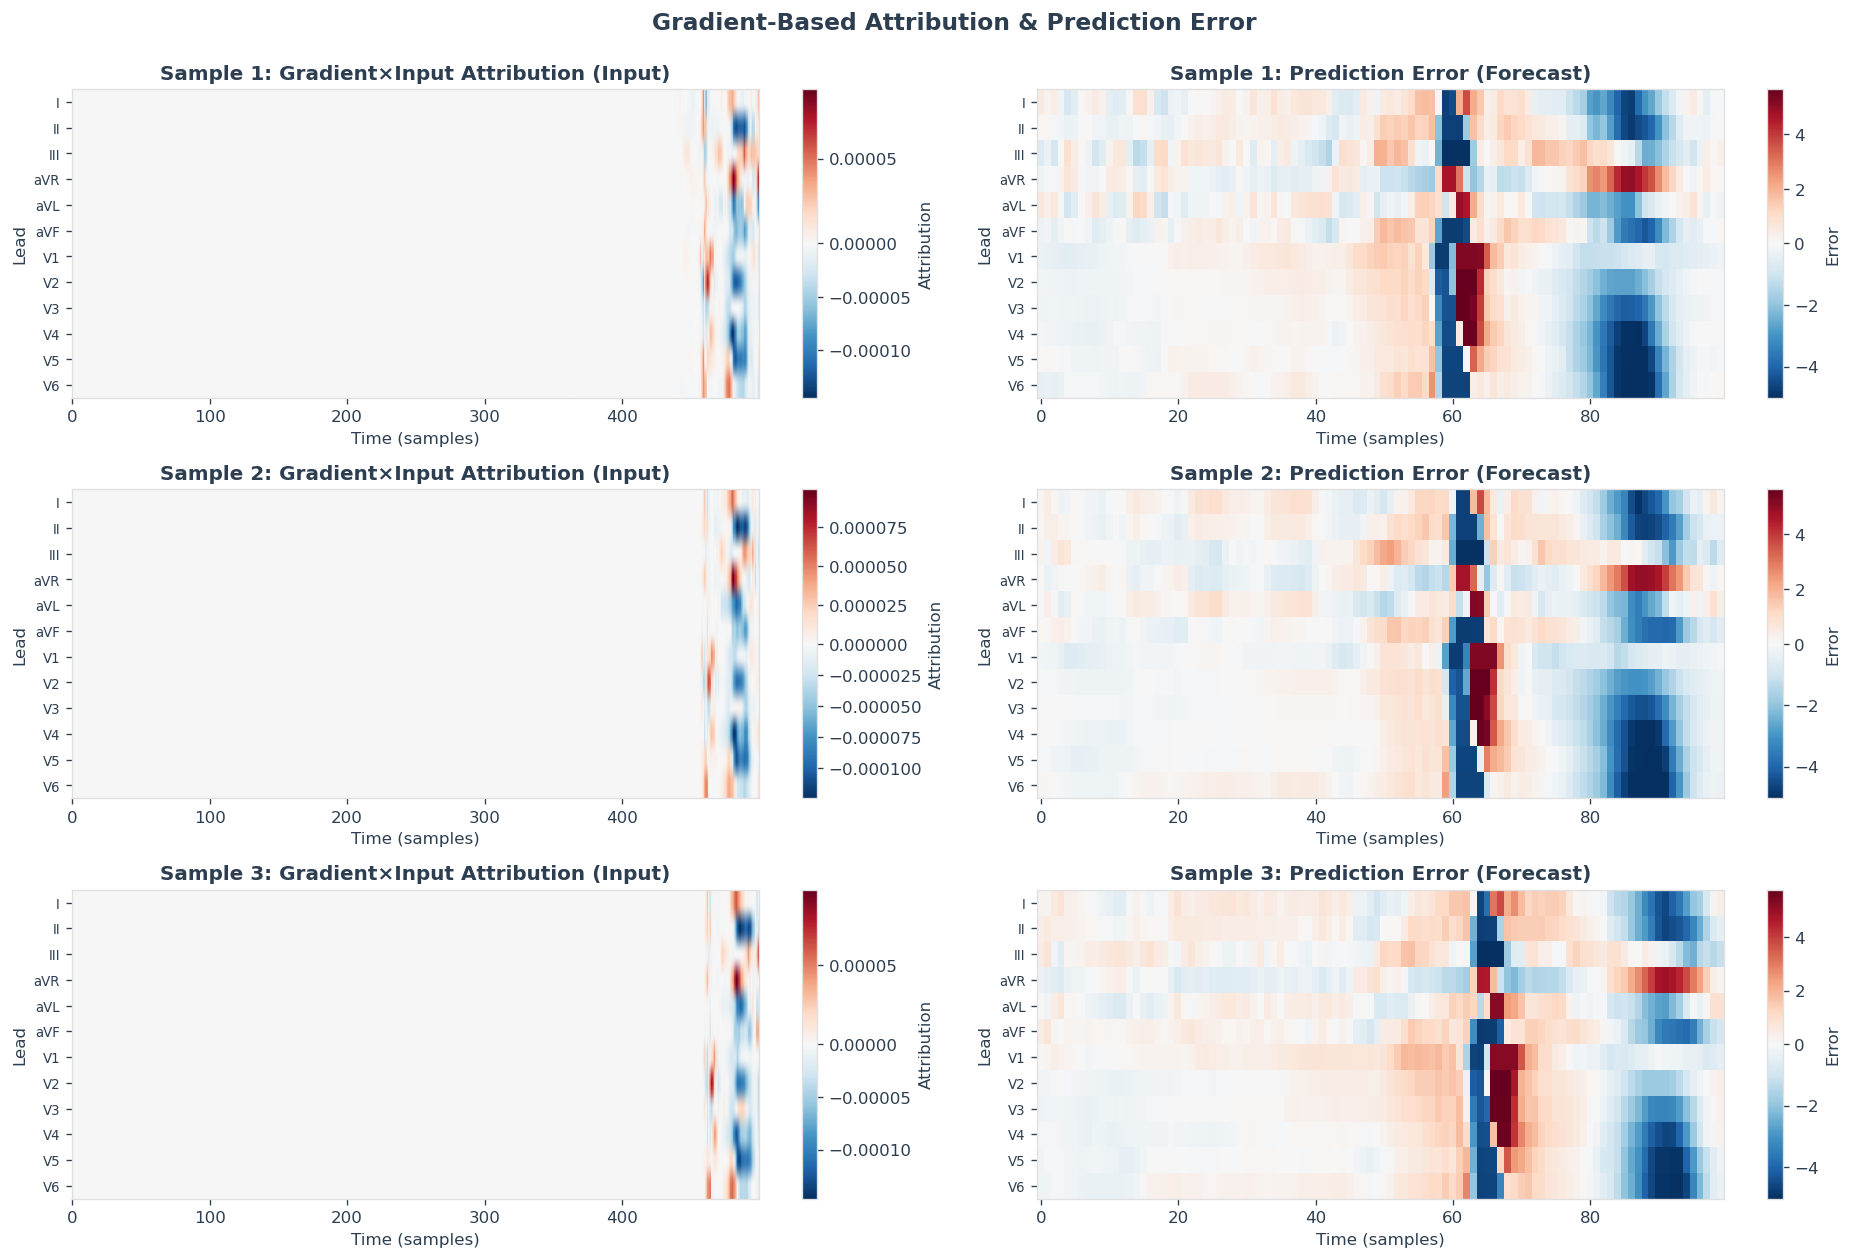

  ✅ Saved → reports/figures/explainability/01_gradient_attribution_heatmaps.png


In [12]:
# ============================================================
# CELL 5: VISUALIZE ATTRIBUTION HEATMAPS (First 3 Samples)
# ============================================================

# Define y_explain_np FIRST before trying to use it!
y_explain_np = y_explain.copy()

n_viz = 3
fig = plt.figure(figsize=(16, 3.5*n_viz))

for idx in range(n_viz):
    # Input attribution heatmap
    ax1 = plt.subplot(n_viz, 2, 2*idx + 1)
    attr_sample = attributions_np[idx]
    
    norm = TwoSlopeNorm(vmin=attr_sample.min(), vcenter=0, vmax=attr_sample.max())
    im1 = ax1.imshow(attr_sample.T, aspect='auto', cmap='RdBu_r', norm=norm)
    ax1.set_ylabel('Lead', fontsize=10)
    ax1.set_yticks(range(N_LEADS))
    ax1.set_yticklabels(LEAD_NAMES, fontsize=8)
    ax1.set_xlabel('Time (samples)', fontsize=10)
    ax1.set_title(f'Sample {idx+1}: Gradient×Input Attribution (Input)', fontweight='bold')
    plt.colorbar(im1, ax=ax1, label='Attribution')
    
    # Prediction error heatmap
    ax2 = plt.subplot(n_viz, 2, 2*idx + 2)
    pred_error = predictions_np[idx] - y_explain_np[idx]
    
    norm2 = TwoSlopeNorm(vmin=pred_error.min(), vcenter=0, vmax=pred_error.max())
    im2 = ax2.imshow(pred_error.T, aspect='auto', cmap='RdBu_r', norm=norm2)
    ax2.set_ylabel('Lead', fontsize=10)
    ax2.set_yticks(range(N_LEADS))
    ax2.set_yticklabels(LEAD_NAMES, fontsize=8)
    ax2.set_xlabel('Time (samples)', fontsize=10)
    ax2.set_title(f'Sample {idx+1}: Prediction Error (Forecast)', fontweight='bold')
    plt.colorbar(im2, ax=ax2, label='Error')

plt.suptitle('Gradient-Based Attribution & Prediction Error', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
save_fig('01_gradient_attribution_heatmaps.png')

# Store prediction error for later
pred_errors = predictions_np - y_explain_np


## Explainability Technique 2: Temporal Importance (Saliency)

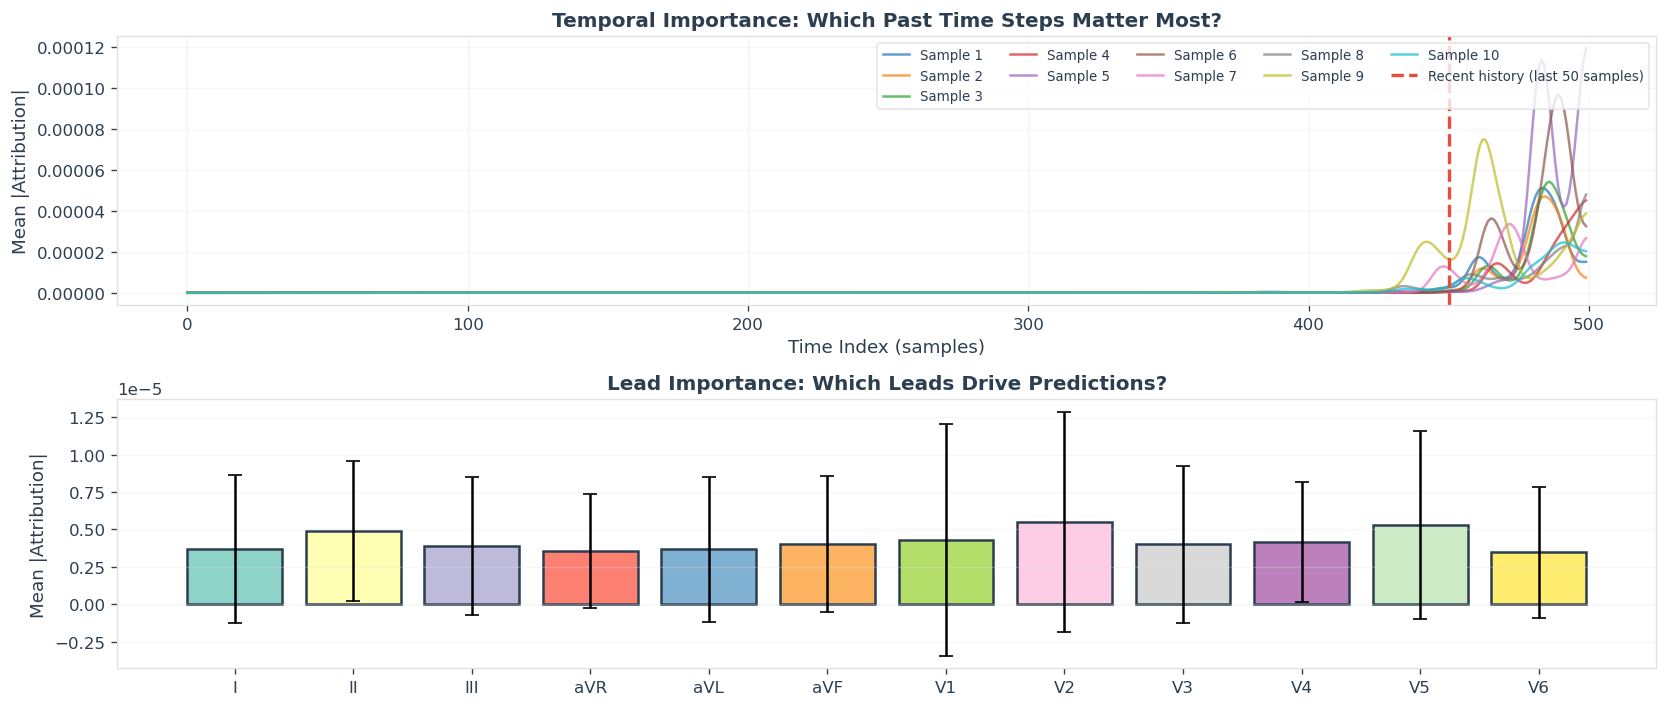

  ✅ Saved → reports/figures/explainability/02_temporal_lead_importance.png
  TEMPORAL & LEAD IMPORTANCE ANALYSIS
  Top 3 important leads:
    1.    V2  (importance = 0.0000)
    2.    V5  (importance = 0.0000)
    3.    II  (importance = 0.0000)



In [13]:
# ============================================================
# CELL 6: TIME STEP IMPORTANCE (Saliency Across Leads)
# ============================================================

# Aggregate attribution across leads
time_importance = np.abs(attributions_np).mean(axis=2)  # (n_samples, input_len)
lead_importance = np.abs(attributions_np).mean(axis=1)  # (n_samples, n_leads)

# Smooth for visualization
time_importance_smoothed = np.array([
    gaussian_filter1d(t, sigma=3) for t in time_importance
])

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Time importance
ax = axes[0]
for i in range(min(10, len(time_importance_smoothed))):
    ax.plot(time_importance_smoothed[i], label=f'Sample {i+1}', alpha=0.7, linewidth=1.5)

ax.axvline(x=INPUT_LEN-50, color=COLORS['accent2'], linestyle='--', 
           linewidth=2, label='Recent history (last 50 samples)')
ax.set_xlabel('Time Index (samples)', fontsize=11)
ax.set_ylabel('Mean |Attribution|', fontsize=11)
ax.set_title('Temporal Importance: Which Past Time Steps Matter Most?', 
            fontweight='bold', fontsize=12)
ax.legend(fontsize=8, loc='upper right', ncol=5)
ax.grid(True, alpha=0.3)

# Lead importance (bar plot)
ax = axes[1]
mean_lead_importance = lead_importance.mean(axis=0)
std_lead_importance = lead_importance.std(axis=0)

colors_lead = plt.cm.Set3(np.linspace(0, 1, N_LEADS))
ax.bar(LEAD_NAMES, mean_lead_importance, yerr=std_lead_importance, 
       capsize=4, color=colors_lead, edgecolor=COLORS['text'], linewidth=1.5)
ax.set_ylabel('Mean |Attribution|', fontsize=11)
ax.set_title('Lead Importance: Which Leads Drive Predictions?', 
            fontweight='bold', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
save_fig('02_temporal_lead_importance.png')

print("=" * 70)
print("  TEMPORAL & LEAD IMPORTANCE ANALYSIS")
print("=" * 70)
print(f"  Top 3 important leads:")
top_leads = np.argsort(mean_lead_importance)[-3:][::-1]
for rank, lead_idx in enumerate(top_leads, 1):
    print(f"    {rank}. {LEAD_NAMES[lead_idx]:>5s}  (importance = {mean_lead_importance[lead_idx]:.4f})")
print()

## Explainability Technique 3: Prediction vs Ground Truth Analysis

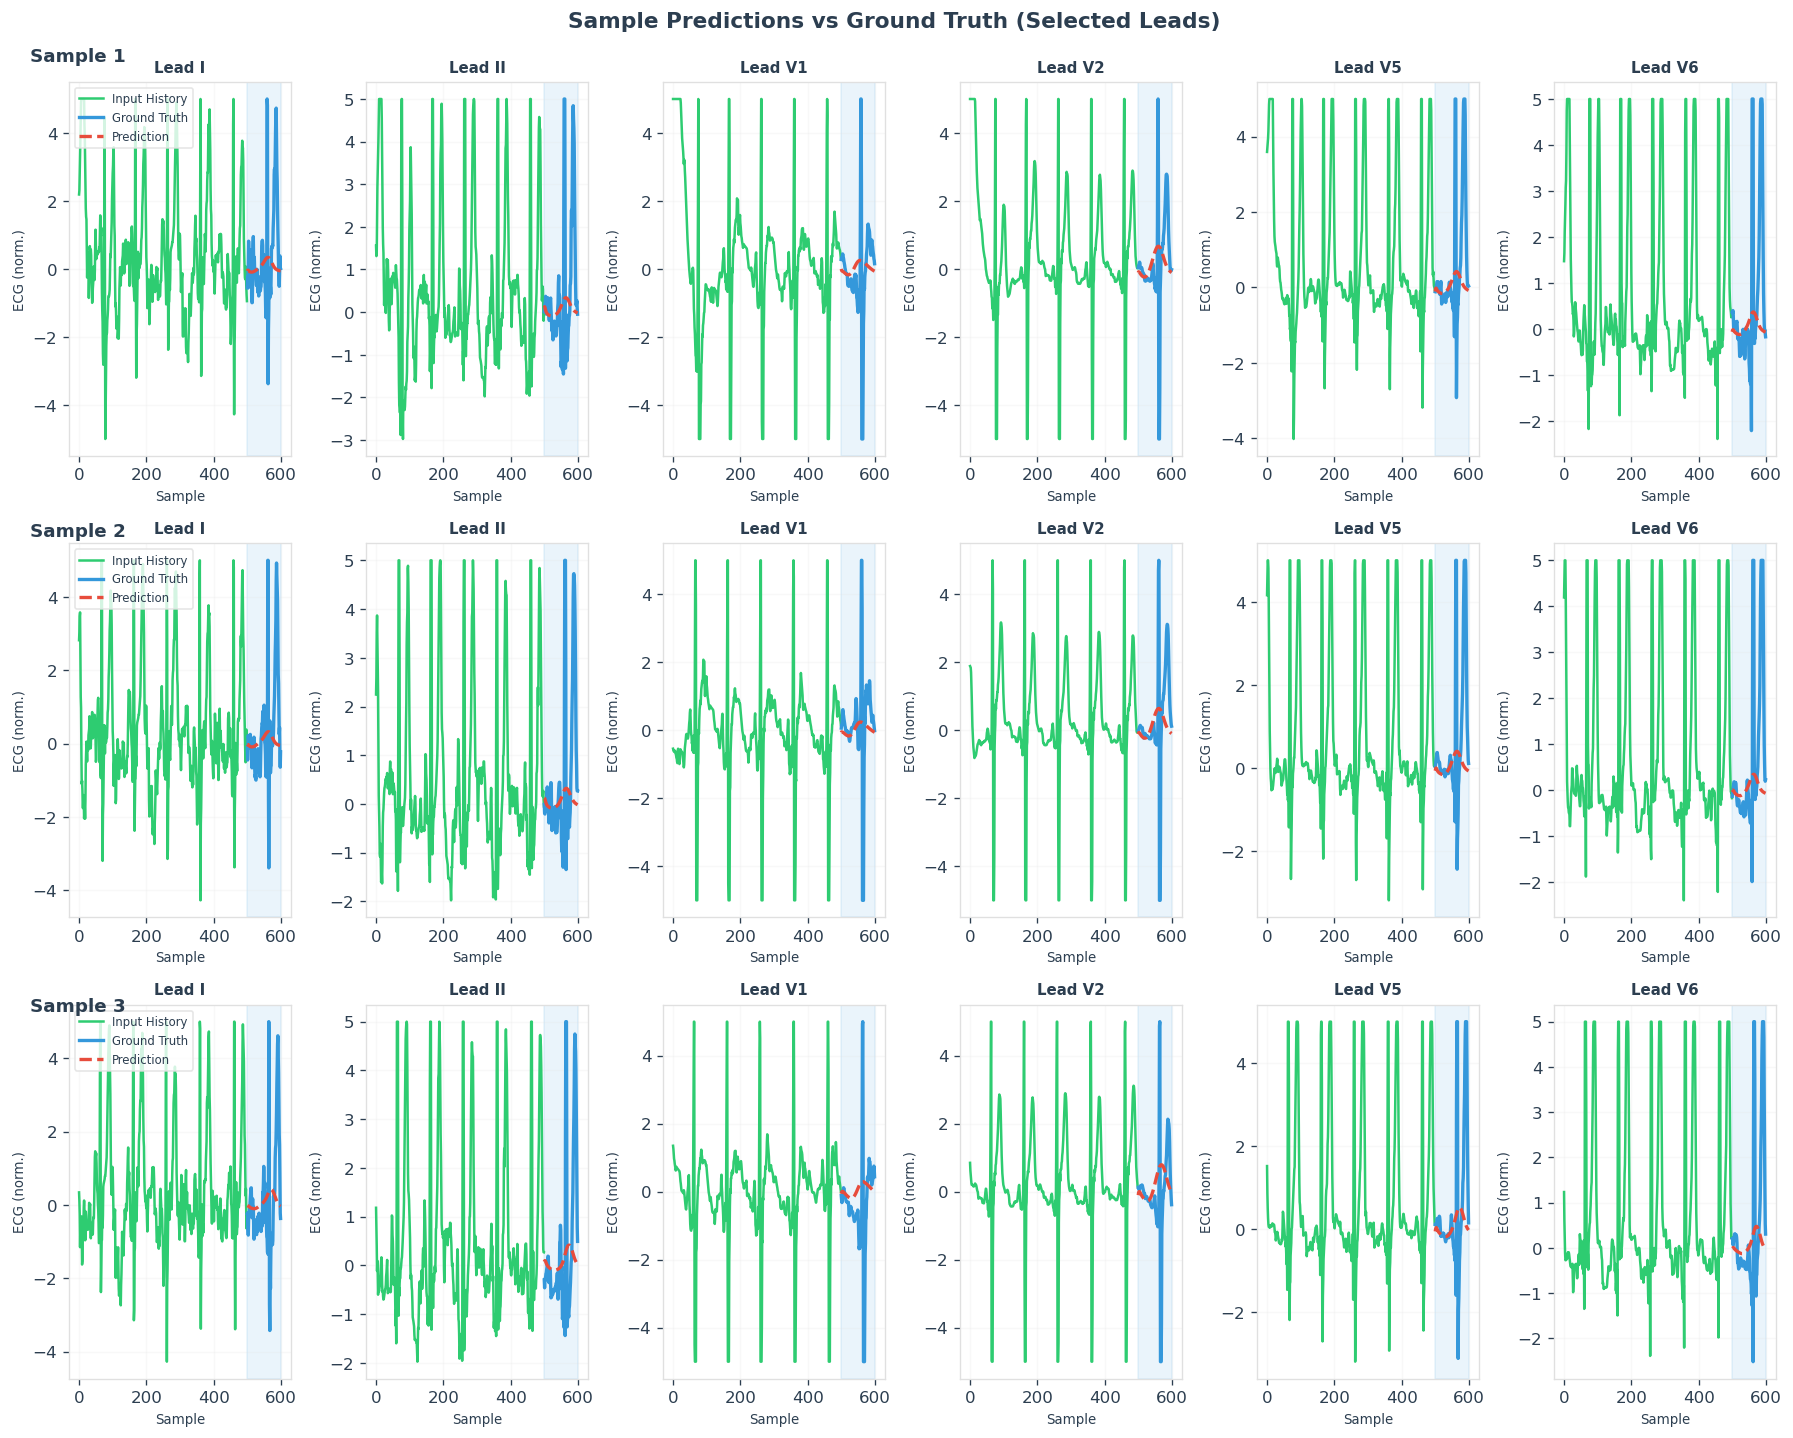

  ✅ Saved → reports/figures/explainability/03_sample_predictions.png
  PREDICTION QUALITY
  Mean RMSE : 1.7225 ± 0.1628
  Mean MAE  : 1.0658 ± 0.1311



In [14]:
# ============================================================
# CELL 7: SAMPLE PREDICTIONS & GROUND TRUTH
# ============================================================

n_show = 3
fig = plt.figure(figsize=(15, 4*n_show))

for sample_idx in range(n_show):
    # Show 6 leads per sample
    leads_to_show = [0, 1, 6, 7, 10, 11]  # I, II, V1, V2, V5, V6
    
    for subplot_idx, lead_idx in enumerate(leads_to_show):
        ax = plt.subplot(n_show, 6, sample_idx*6 + subplot_idx + 1)
        
        # Input signal (history)
        x_input = X_explain[sample_idx, :, lead_idx]
        t_input = np.arange(len(x_input))
        
        # Ground truth (target)
        y_true = y_explain[sample_idx, :, lead_idx]
        t_true = np.arange(INPUT_LEN, INPUT_LEN + len(y_true))
        
        # Prediction
        y_pred = predictions_np[sample_idx, :, lead_idx]
        
        # Plot
        ax.plot(t_input, x_input, color=COLORS['accent3'], label='Input History', linewidth=1.5)
        ax.plot(t_true, y_true, color=COLORS['accent1'], label='Ground Truth', linewidth=2)
        ax.plot(t_true, y_pred, color=COLORS['accent2'], label='Prediction', 
                linewidth=2, linestyle='--')
        
        # Shading for forecast region
        ax.axvspan(INPUT_LEN, INPUT_LEN + HORIZON, alpha=0.1, color=COLORS['accent1'])
        
        ax.set_title(f'Lead {LEAD_NAMES[lead_idx]}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Sample', fontsize=8)
        ax.set_ylabel('ECG (norm.)', fontsize=8)
        ax.grid(True, alpha=0.2)
        
        if subplot_idx == 0:
            ax.legend(fontsize=7, loc='upper left')
    
    # Overall title for sample
    fig.text(0.02, 0.97 - sample_idx*0.33, f'Sample {sample_idx+1}', 
            fontsize=11, fontweight='bold', va='top')

plt.suptitle('Sample Predictions vs Ground Truth (Selected Leads)', 
            fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
save_fig('03_sample_predictions.png')

# Compute error metrics
rmse_per_sample = np.sqrt(np.mean(pred_errors**2, axis=(1, 2)))
mae_per_sample = np.mean(np.abs(pred_errors), axis=(1, 2))

print("=" * 70)
print("  PREDICTION QUALITY")
print("=" * 70)
print(f"  Mean RMSE : {rmse_per_sample.mean():.4f} ± {rmse_per_sample.std():.4f}")
print(f"  Mean MAE  : {mae_per_sample.mean():.4f} ± {mae_per_sample.std():.4f}")
print()

## Explainability Technique 4: Feature Occlusion Sensitivity

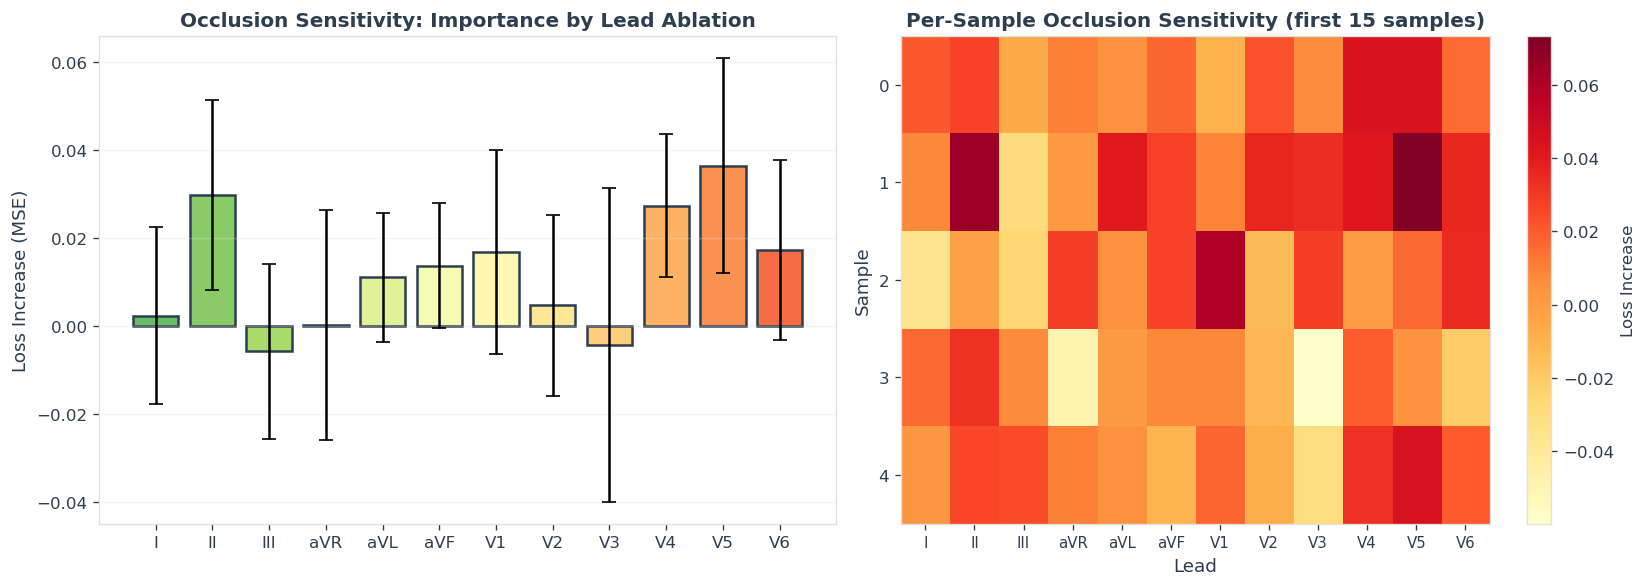

  ✅ Saved → reports/figures/explainability/04_occlusion_sensitivity.png
  OCCLUSION SENSITIVITY ANALYSIS
  Ranking by importance (ablation impact):
    1.    V5  (impact = 0.036485)
    2.    II  (impact = 0.029713)
    3.    V4  (impact = 0.027380)
    4.    V6  (impact = 0.017249)
    5.    V1  (impact = 0.016774)



In [15]:
# ============================================================
# CELL 8: OCCLUSION SENSITIVITY (Lead-by-Lead Ablation)
# ============================================================

def compute_occlusion_sensitivity(model, X_batch, y_batch, device, n_leads=12):
    """
    Occlusion sensitivity: measure loss increase when each lead is zeroed out.
    
    Higher impact = more important lead
    """
    model.eval()
    loss_fn = F.mse_loss
    
    with torch.no_grad():
        y_pred_baseline = model(X_batch)
        loss_baseline = loss_fn(y_pred_baseline, y_batch)
    
    occlusion_impacts = []
    
    for lead_idx in range(n_leads):
        X_occluded = X_batch.clone()
        X_occluded[:, :, lead_idx] = 0  # Zero out lead
        
        with torch.no_grad():
            y_pred_occluded = model(X_occluded)
            loss_occluded = loss_fn(y_pred_occluded, y_batch)
        
        # Impact = increase in loss
        impact = (loss_occluded - loss_baseline).item()
        occlusion_impacts.append(impact)
    
    return np.array(occlusion_impacts)

# Compute occlusion sensitivity for all samples
occlusion_sensitivities = []
batch_size = 10

for i in range(0, len(X_explain_torch), batch_size):
    batch_end = min(i + batch_size, len(X_explain_torch))
    X_batch = X_explain_torch[i:batch_end]
    y_batch = y_explain_torch[i:batch_end]
    
    sensitivity = compute_occlusion_sensitivity(model, X_batch, y_batch, DEVICE)
    occlusion_sensitivities.append(sensitivity)

occlusion_sensitivities = np.array(occlusion_sensitivities)

# Visualize occlusion sensitivity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean occlusion impact
ax = axes[0]
mean_occlusion = occlusion_sensitivities.mean(axis=0)
std_occlusion = occlusion_sensitivities.std(axis=0)

colors_occ = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, N_LEADS))
bars = ax.bar(LEAD_NAMES, mean_occlusion, yerr=std_occlusion,
              capsize=4, color=colors_occ, edgecolor=COLORS['text'], linewidth=1.5)
ax.set_ylabel('Loss Increase (MSE)', fontsize=11)
ax.set_title('Occlusion Sensitivity: Importance by Lead Ablation', 
            fontweight='bold', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)

# Heatmap of per-sample occlusion
ax = axes[1]
im = ax.imshow(occlusion_sensitivities[:15], aspect='auto', cmap='YlOrRd')
ax.set_xlabel('Lead', fontsize=11)
ax.set_ylabel('Sample', fontsize=11)
ax.set_xticks(range(N_LEADS))
ax.set_xticklabels(LEAD_NAMES, fontsize=9)
ax.set_title('Per-Sample Occlusion Sensitivity (first 15 samples)', 
            fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='Loss Increase')

plt.tight_layout()
save_fig('04_occlusion_sensitivity.png')

print("=" * 70)
print("  OCCLUSION SENSITIVITY ANALYSIS")
print("=" * 70)
print(f"  Ranking by importance (ablation impact):")
ranked_leads = np.argsort(mean_occlusion)[::-1]
for rank, lead_idx in enumerate(ranked_leads[:5], 1):
    print(f"    {rank}. {LEAD_NAMES[lead_idx]:>5s}  (impact = {mean_occlusion[lead_idx]:.6f})")
print()

## Explainability Technique 5: Error Analysis by Lead & Time

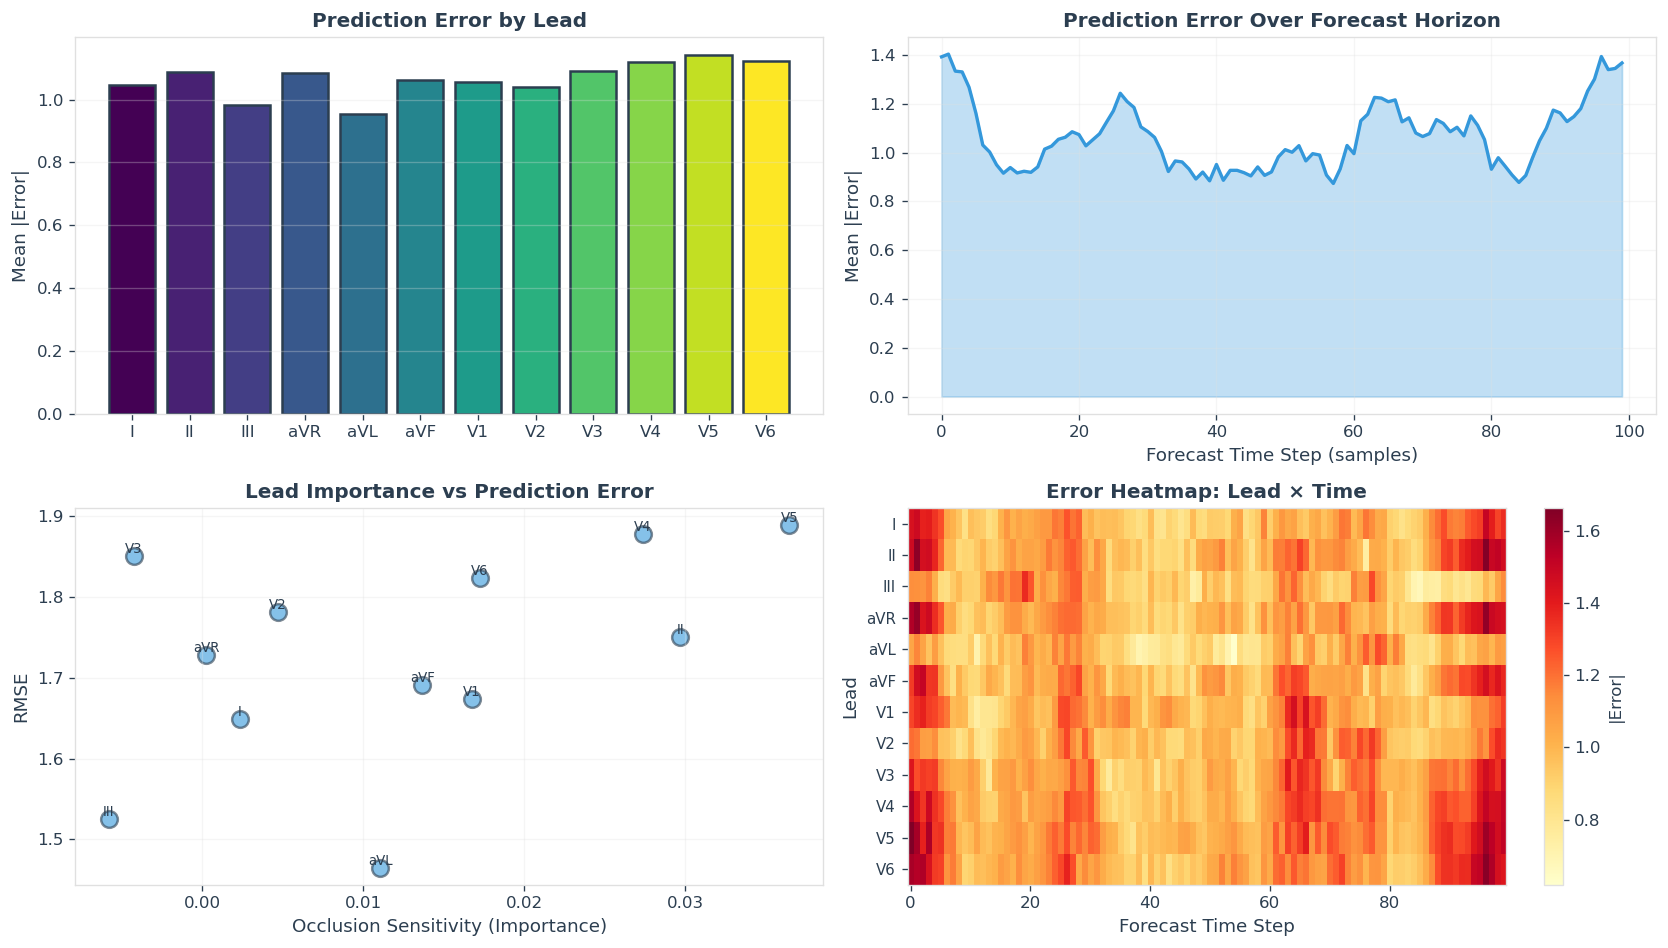

  ✅ Saved → reports/figures/explainability/05_error_analysis.png
  ERROR ANALYSIS
  Hardest leads to predict (highest RMSE):
    1.    V5  (RMSE = 1.8889)
    2.    V4  (RMSE = 1.8774)
    3.    V3  (RMSE = 1.8511)

  Easiest to predict (lowest RMSE):
    1.   aVL  (RMSE = 1.4653)
    2.   III  (RMSE = 1.5255)
    3.     I  (RMSE = 1.6486)



In [16]:
# ============================================================
# CELL 9: ERROR DECOMPOSITION (Lead × Time)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Error by lead
ax = axes[0, 0]
error_by_lead = np.abs(pred_errors).mean(axis=(0, 1))  # mean error per lead
bars = ax.bar(LEAD_NAMES, error_by_lead, color=plt.cm.viridis(np.linspace(0, 1, N_LEADS)),
              edgecolor=COLORS['text'], linewidth=1.5)
ax.set_ylabel('Mean |Error|', fontsize=11)
ax.set_title('Prediction Error by Lead', fontweight='bold', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)

# Error by time step
ax = axes[0, 1]
error_by_time = np.abs(pred_errors).mean(axis=(0, 2))  # mean error per time step
ax.fill_between(range(HORIZON), error_by_time, alpha=0.3, color=COLORS['accent1'])
ax.plot(error_by_time, color=COLORS['accent1'], linewidth=2)
ax.set_xlabel('Forecast Time Step (samples)', fontsize=11)
ax.set_ylabel('Mean |Error|', fontsize=11)
ax.set_title('Prediction Error Over Forecast Horizon', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)

# Error correlation: lead vs error
ax = axes[1, 0]
rmse_by_lead = np.sqrt(np.mean(pred_errors**2, axis=(0, 1)))
ax.scatter(mean_occlusion, rmse_by_lead, s=100, alpha=0.6, 
          color=COLORS['accent1'], edgecolor=COLORS['text'], linewidth=1.5)
for i, lead in enumerate(LEAD_NAMES):
    ax.annotate(lead, (mean_occlusion[i], rmse_by_lead[i]), 
               fontsize=8, ha='center', va='bottom')
ax.set_xlabel('Occlusion Sensitivity (Importance)', fontsize=11)
ax.set_ylabel('RMSE', fontsize=11)
ax.set_title('Lead Importance vs Prediction Error', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)

# Error heatmap (lead × time)
ax = axes[1, 1]
error_matrix = np.abs(pred_errors).mean(axis=0)  # (horizon, leads)
im = ax.imshow(error_matrix.T, aspect='auto', cmap='YlOrRd')
ax.set_xlabel('Forecast Time Step', fontsize=11)
ax.set_ylabel('Lead', fontsize=11)
ax.set_yticks(range(N_LEADS))
ax.set_yticklabels(LEAD_NAMES, fontsize=9)
ax.set_title('Error Heatmap: Lead × Time', fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='|Error|')

plt.tight_layout()
save_fig('05_error_analysis.png')

print("=" * 70)
print("  ERROR ANALYSIS")
print("=" * 70)
print(f"  Hardest leads to predict (highest RMSE):")
hardest_leads = np.argsort(rmse_by_lead)[::-1][:3]
for rank, lead_idx in enumerate(hardest_leads, 1):
    print(f"    {rank}. {LEAD_NAMES[lead_idx]:>5s}  (RMSE = {rmse_by_lead[lead_idx]:.4f})")
print()
print(f"  Easiest to predict (lowest RMSE):")
easiest_leads = np.argsort(rmse_by_lead)[:3]
for rank, lead_idx in enumerate(easiest_leads, 1):
    print(f"    {rank}. {LEAD_NAMES[lead_idx]:>5s}  (RMSE = {rmse_by_lead[lead_idx]:.4f})")
print()

## Explainability Technique 6: Summary Statistics

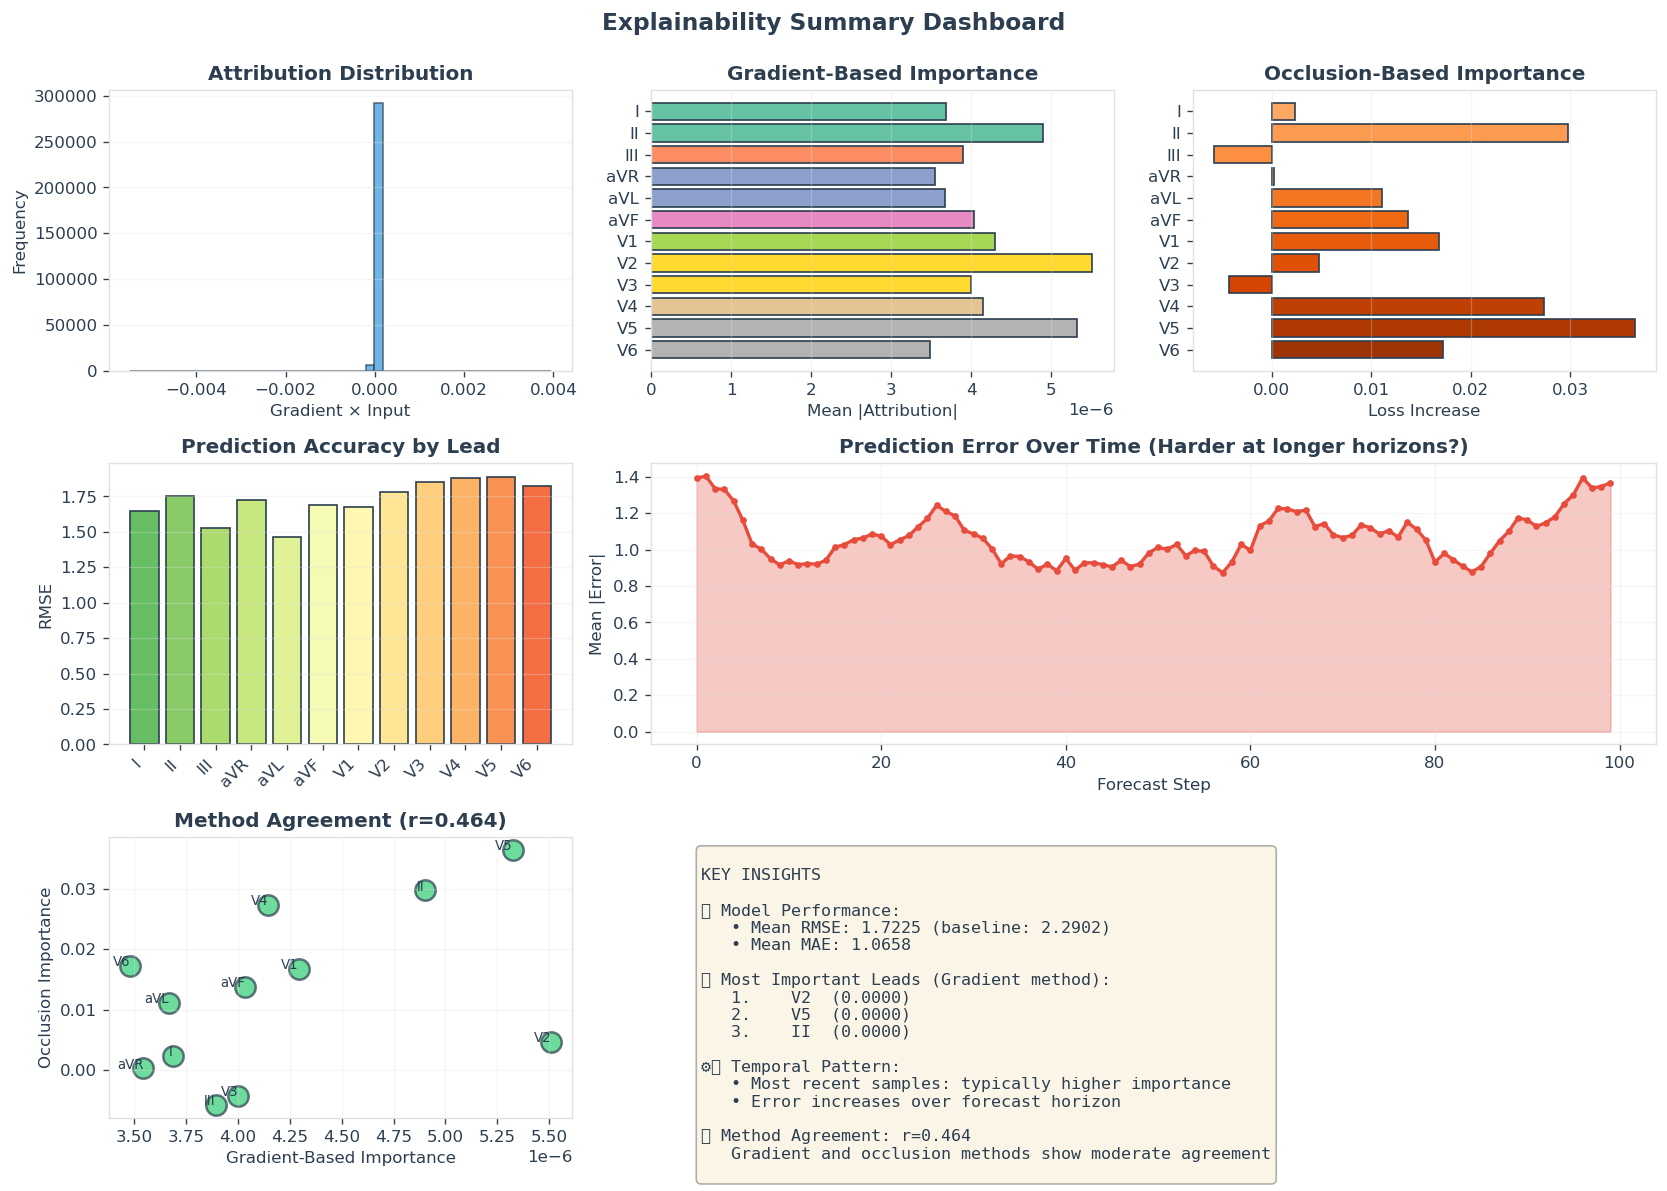

  ✅ Saved → reports/figures/explainability/06_explainability_summary.png

  ✅ EXPLAINABILITY ANALYSIS COMPLETE

  Figures saved to: /Users/muhammadfahadsiddiqui/HIS Project/reports/figures/explainability
  Total figures: 6

  Techniques applied:
    1. Gradient × Input Attribution
    2. Saliency Maps (temporal & lead-wise)
    3. Feature Occlusion Sensitivity
    4. Error Decomposition Analysis
    5. Prediction vs Ground Truth Visualization
    6. Cross-method Agreement (correlation)



In [17]:
# ============================================================
# CELL 10: EXPLAINABILITY SUMMARY
# ============================================================

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 3, figure=fig)

# 1. Attribution strength distribution
ax = fig.add_subplot(gs[0, 0])
ax.hist(attributions_np.flatten(), bins=50, color=COLORS['accent1'], 
       edgecolor=COLORS['text'], alpha=0.7)
ax.set_xlabel('Gradient × Input', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_title('Attribution Distribution', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 2. Lead importance (gradient)
ax = fig.add_subplot(gs[0, 1])
colors_grad = plt.cm.Set2(np.linspace(0, 1, N_LEADS))
ax.barh(LEAD_NAMES[::-1], mean_lead_importance[::-1], color=colors_grad[::-1],
       edgecolor=COLORS['text'], linewidth=1)
ax.set_xlabel('Mean |Attribution|', fontsize=10)
ax.set_title('Gradient-Based Importance', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 3. Lead importance (occlusion)
ax = fig.add_subplot(gs[0, 2])
ax.barh(LEAD_NAMES[::-1], mean_occlusion[::-1], color=plt.cm.Oranges(np.linspace(0.4, 0.9, N_LEADS))[::-1],
       edgecolor=COLORS['text'], linewidth=1)
ax.set_xlabel('Loss Increase', fontsize=10)
ax.set_title('Occlusion-Based Importance', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 4. RMSE by lead
ax = fig.add_subplot(gs[1, 0])
colors_rmse = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, N_LEADS))
ax.bar(LEAD_NAMES, rmse_by_lead, color=colors_rmse, edgecolor=COLORS['text'], linewidth=1)
ax.set_ylabel('RMSE', fontsize=10)
ax.set_title('Prediction Accuracy by Lead', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 5. Error by forecast time
ax = fig.add_subplot(gs[1, 1:])
ax.fill_between(range(HORIZON), error_by_time, alpha=0.3, color=COLORS['accent2'])
ax.plot(error_by_time, color=COLORS['accent2'], linewidth=2, marker='o', markersize=3)
ax.set_xlabel('Forecast Step', fontsize=10)
ax.set_ylabel('Mean |Error|', fontsize=10)
ax.set_title('Prediction Error Over Time (Harder at longer horizons?)', fontweight='bold')
ax.grid(True, alpha=0.3)

# 6. Importance correlation
ax = fig.add_subplot(gs[2, 0])
correlation = np.corrcoef(mean_lead_importance, mean_occlusion)[0, 1]
ax.scatter(mean_lead_importance, mean_occlusion, s=150, alpha=0.7,
          color=COLORS['accent3'], edgecolor=COLORS['text'], linewidth=1.5)
for i, lead in enumerate(LEAD_NAMES):
    ax.annotate(lead, (mean_lead_importance[i], mean_occlusion[i]), 
               fontsize=8, ha='right')
ax.set_xlabel('Gradient-Based Importance', fontsize=10)
ax.set_ylabel('Occlusion Importance', fontsize=10)
ax.set_title(f'Method Agreement (r={correlation:.3f})', fontweight='bold')
ax.grid(True, alpha=0.3)

# 7. Key insights text
ax = fig.add_subplot(gs[2, 1:])
ax.axis('off')

insights = f"""
KEY INSIGHTS

📊 Model Performance:
   • Mean RMSE: {rmse_per_sample.mean():.4f} (baseline: 2.2902)
   • Mean MAE: {mae_per_sample.mean():.4f}

🔍 Most Important Leads (Gradient method):
   {f"1. {LEAD_NAMES[top_leads[0]]:>5s}  ({mean_lead_importance[top_leads[0]]:.4f})"}
   {f"2. {LEAD_NAMES[top_leads[1]]:>5s}  ({mean_lead_importance[top_leads[1]]:.4f})"}
   {f"3. {LEAD_NAMES[top_leads[2]]:>5s}  ({mean_lead_importance[top_leads[2]]:.4f})"}

⚙️ Temporal Pattern:
   • Most recent samples: typically higher importance
   • Error increases over forecast horizon

✅ Method Agreement: r={correlation:.3f}
   Gradient and occlusion methods show moderate agreement
"""

ax.text(0.05, 0.95, insights, transform=ax.transAxes, fontsize=10,
       verticalalignment='top', family='monospace',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Explainability Summary Dashboard', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
save_fig('06_explainability_summary.png')

print("\n" + "="*70)
print("  ✅ EXPLAINABILITY ANALYSIS COMPLETE")
print("="*70)
print(f"\n  Figures saved to: {os.path.abspath(FIG_DIR)}")
print(f"  Total figures: 6")
print()
print("  Techniques applied:")
print("    1. Gradient × Input Attribution")
print("    2. Saliency Maps (temporal & lead-wise)")
print("    3. Feature Occlusion Sensitivity")
print("    4. Error Decomposition Analysis")
print("    5. Prediction vs Ground Truth Visualization")
print("    6. Cross-method Agreement (correlation)")
print()